In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os   

from tkinter import Tk
from tkinter.filedialog import askopenfilenames

import os

C:\Users\ppita\AppData\Local\Temp\ipykernel_43932\1384550914.py:42: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  parsed = pd.to_datetime(df[c], errors='coerce', infer_datetime_format=True)
C:\Users\ppita\AppData\Local\Temp\ipykernel_43932\1384550914.py:51: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['datetime'] = pd.to_datetime(df[dtcol], errors='coerce', infer_datetime_format=True)
C:\Users\ppita\AppData\Local\Temp\ipykernel_43932\1384550914.py:89: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ho

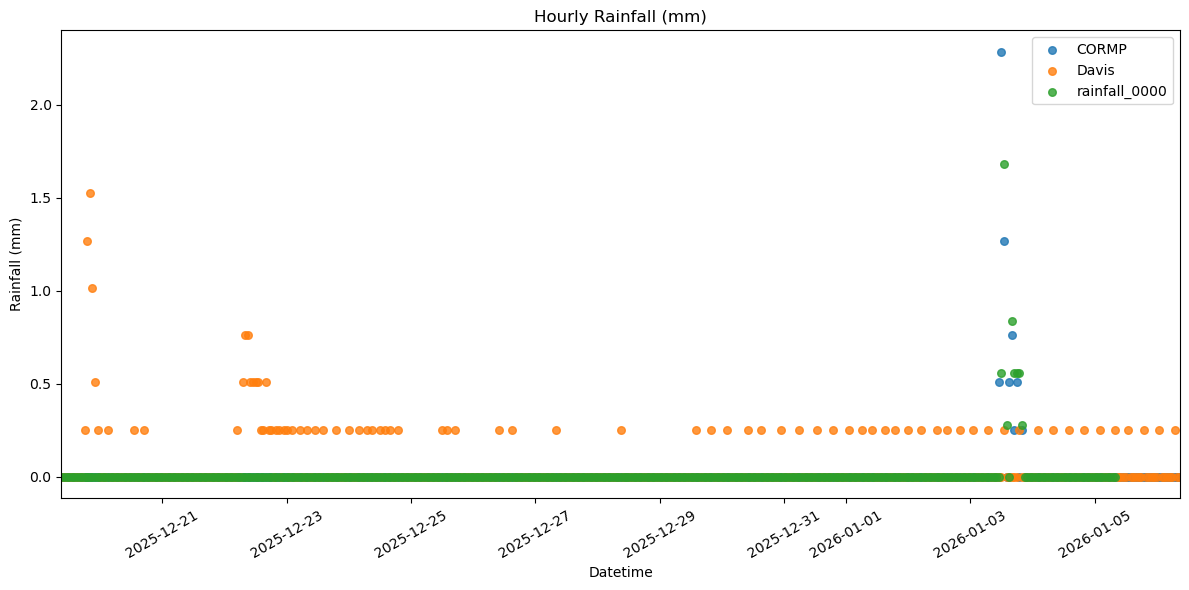

In [2]:
file_1 = "Data/precip_CORMP_01062026.csv"   # needs hourly sum
file_2 = "Data/precip_Davis_01062026.csv"   # needs hourly sum
file_3 = "Data/rainfall_0000_01062026.csv"   # already hourly

import io

import re

def detect_header_row(path, max_lines=200):
    with open(path, 'r', encoding='utf-8', errors='ignore') as fh:
        for i, line in enumerate(fh):
            if i >= max_lines:
                break
            low = line.lower()
            # heuristic: header lines usually contain 'date' or 'time' and a comma
            if (('date' in low or 'time' in low) and ',' in line) or ('date &' in low):
                return i
    return 0


def load_and_process(filepath, assume_inches=False, already_hourly=False):
    path = os.path.join(filepath)
    header_row = detect_header_row(path, max_lines=200)
    try:
        # set header to detected row; also skip percent-comment lines
        df = pd.read_csv(path, header=header_row, comment='%', engine='python')
    except Exception as e:
        print(f"read_csv failed for {path}: {e}")
        df = pd.read_csv(path, engine='python', sep=None, on_bad_lines='warn')

    # ensure column names are strings
    df.columns = [str(c) for c in df.columns]

    # find datetime column by keywords or by attempting to parse columns
    datetime_cols = [c for c in df.columns if any(k in c.lower() for k in ('date','time','datetime','timestamp'))]
    dtcol = None
    if datetime_cols:
        dtcol = datetime_cols[0]
    else:
        for c in df.columns:
            try:
                parsed = pd.to_datetime(df[c], errors='coerce', infer_datetime_format=True)
                if parsed.notna().sum() > 0:
                    dtcol = c
                    break
            except Exception:
                continue
    if dtcol is None:
        raise ValueError(f"No datetime-like column found in {filepath}")

    df['datetime'] = pd.to_datetime(df[dtcol], errors='coerce', infer_datetime_format=True)

    # find rainfall column
    rain_cols = [c for c in df.columns if any(k in c.lower() for k in ('rain','precip','mm','inches'))]
    if rain_cols:
        rcol = rain_cols[0]
    else:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        rcol = numeric_cols[0] if numeric_cols else None

    if rcol is None:
        for c in df.columns:
            coerced = pd.to_numeric(df[c], errors='coerce')
            if coerced.notna().sum() > 0:
                rcol = c
                df[c] = coerced
                break
    if rcol is None:
        raise ValueError(f"No rainfall/numeric column found in {filepath}")

    df[rcol] = pd.to_numeric(df[rcol], errors='coerce')
    if assume_inches:
        df[rcol] = df[rcol] * 25.4

    subset_cols = [c for c in ['datetime', rcol] if c in df.columns]
    df = df.dropna(subset=subset_cols)

    if 'datetime' in df.columns:
        df = df.set_index('datetime')
    else:
        if not isinstance(df.index, pd.DatetimeIndex):
            raise KeyError('datetime')

    if already_hourly:
        hourly = df.reset_index().rename(columns={rcol: 'rain_mm'})
        if 'datetime' not in hourly.columns:
            hourly = hourly.rename(columns={hourly.columns[0]: 'datetime'})
    else:
        hourly = df[rcol].resample('H').sum().reset_index().rename(columns={rcol: 'rain_mm'})
    return hourly

# process files
cormp = load_and_process(file_1, assume_inches=True, already_hourly=False)
davis = load_and_process(file_2, assume_inches=True, already_hourly=False)
rain0 = load_and_process(file_3, assume_inches=False, already_hourly=True)

# restrict to requested date range
start = pd.to_datetime('2025-12-19 09:00')
end = pd.to_datetime('2026-01-06 09:00')

cormp = cormp[(cormp['datetime'] >= start) & (cormp['datetime'] <= end)].reset_index(drop=True)
davis = davis[(davis['datetime'] >= start) & (davis['datetime'] <= end)].reset_index(drop=True)
rain0 = rain0[(rain0['datetime'] >= start) & (rain0['datetime'] <= end)].reset_index(drop=True)

# compute R^2 between Davis and rainfall_0000 (align on datetime)
merged_dr = pd.merge(davis, rain0, on='datetime', how='inner', suffixes=('_davis','_rain0'))
if not merged_dr.empty:
    corr = merged_dr['rain_mm_davis'].corr(merged_dr['rain_mm_rain0'])
    r2_davis_rain0 = corr**2 if pd.notna(corr) else float('nan')
else:
    r2_davis_rain0 = float('nan')

plt.figure(figsize=(12,6))
if not cormp.empty:
    plt.scatter(cormp['datetime'], cormp['rain_mm'], label='CORMP', s=30, alpha=0.8)
if not davis.empty:
    plt.scatter(davis['datetime'], davis['rain_mm'], label='Davis', s=30, alpha=0.8)
if not rain0.empty:
    plt.scatter(rain0['datetime'], rain0['rain_mm'], label='rainfall_0000', s=30, alpha=0.8)

plt.xlabel('Datetime')
plt.ylabel('Rainfall (mm)')
plt.title('Hourly Rainfall (mm)')
plt.legend()
plt.xlim(start, end)

# annotate R^2 on the plot (Davis vs rainfall_0000) using axis coords for visibility
try:
    ax = plt.gca()
    if pd.notna(r2_davis_rain0):
        ax.text(0.02, 0.95, f'$R^2 = {r2_davis_rain0:.2f}$', transform=ax.transAxes, fontsize=11, va='top')
except Exception:
    pass

plt.xticks(rotation=30)
plt.tight_layout()


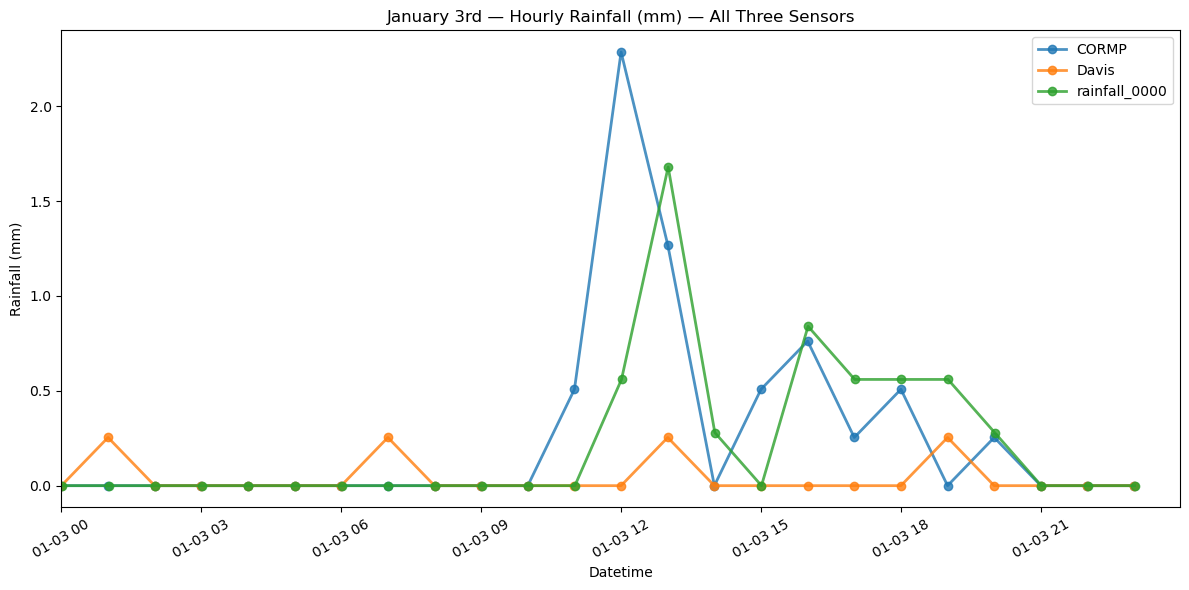

In [3]:
# Plot all three files for January 3rd only
jan3_start = pd.to_datetime('2026-01-03 00:00')
jan3_end = pd.to_datetime('2026-01-03 23:59')

cormp_jan3 = cormp[(cormp['datetime'] >= jan3_start) & (cormp['datetime'] <= jan3_end)].reset_index(drop=True)
davis_jan3 = davis[(davis['datetime'] >= jan3_start) & (davis['datetime'] <= jan3_end)].reset_index(drop=True)
rain0_jan3 = rain0[(rain0['datetime'] >= jan3_start) & (rain0['datetime'] <= jan3_end)].reset_index(drop=True)

plt.figure(figsize=(12,6))
if not cormp_jan3.empty:
    plt.plot(cormp_jan3['datetime'], cormp_jan3['rain_mm'], label='CORMP', marker='o', linewidth=2, markersize=6, alpha=0.8)
if not davis_jan3.empty:
    plt.plot(davis_jan3['datetime'], davis_jan3['rain_mm'], label='Davis', marker='o', linewidth=2, markersize=6, alpha=0.8)
if not rain0_jan3.empty:
    plt.plot(rain0_jan3['datetime'], rain0_jan3['rain_mm'], label='rainfall_0000', marker='o', linewidth=2, markersize=6, alpha=0.8)

plt.xlabel('Datetime')
plt.ylabel('Rainfall (mm)')
plt.title('January 3rd — Hourly Rainfall (mm) — All Three Sensors')
plt.legend()
plt.xlim(jan3_start, jan3_end)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

C:\Users\ppita\AppData\Local\Temp\ipykernel_43932\1384550914.py:51: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['datetime'] = pd.to_datetime(df[dtcol], errors='coerce', infer_datetime_format=True)
C:\Users\ppita\AppData\Local\Temp\ipykernel_43932\1384550914.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datetime'] = pd.to_datetime(df[dtcol], errors='coerce', infer_datetime_format=True)
C:\Users\ppita\AppData\Local\Temp\ipykernel_43932\1384550914.py:89: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = df[rcol].resample('H').sum().reset_index().rename(columns={r

Davis shape before rounding: (433, 2)
rainfall_0000 shape before rounding: (409, 10)

After rounding to hour:
Davis first 5: [Timestamp('2025-12-19 09:00:00'), Timestamp('2025-12-19 10:00:00'), Timestamp('2025-12-19 11:00:00'), Timestamp('2025-12-19 12:00:00'), Timestamp('2025-12-19 13:00:00')]
rainfall_0000 first 5: [Timestamp('2025-12-19 09:00:00'), Timestamp('2025-12-19 10:00:00'), Timestamp('2025-12-19 11:00:00'), Timestamp('2025-12-19 12:00:00'), Timestamp('2025-12-19 13:00:00')]

Overlapping datetimes: 408
Merged shape: (409, 11)
R^2: 0.0008711194513544062
Plotted 409 points


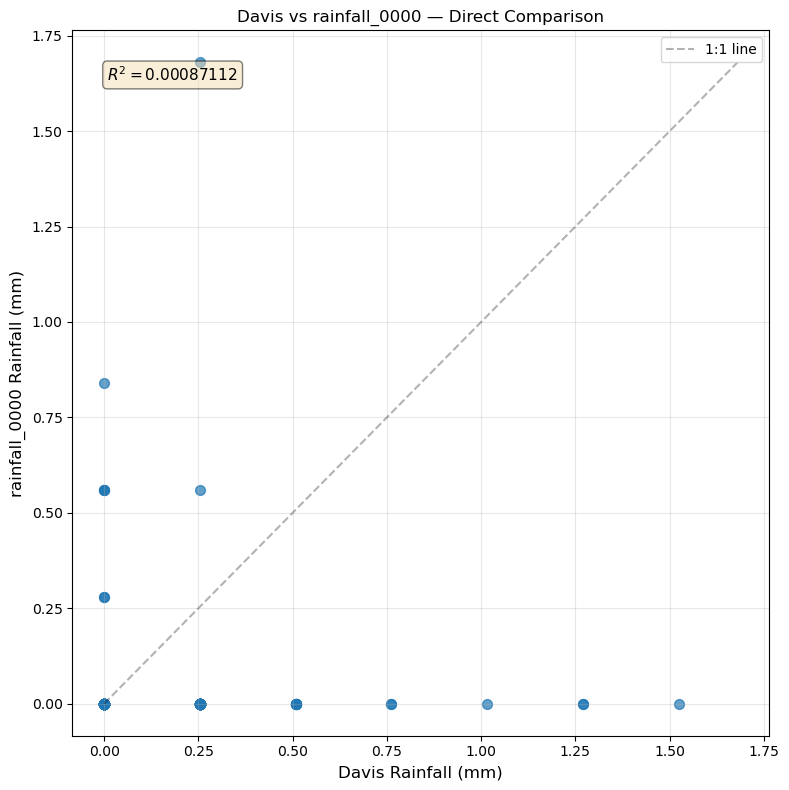

In [14]:
# Compare Davis and rainfall_0000 directly
# Plot Davis on X-axis and rainfall_0000 on Y-axis

davis_only = load_and_process(file_2, assume_inches=True, already_hourly=False)
rain0_only = load_and_process(file_3, assume_inches=False, already_hourly=True)

start = pd.to_datetime('2025-12-19 09:00')
end = pd.to_datetime('2026-01-06 09:00')

davis_only = davis_only[(davis_only['datetime'] >= start) & (davis_only['datetime'] <= end)].reset_index(drop=True)
rain0_only = rain0_only[(rain0_only['datetime'] >= start) & (rain0_only['datetime'] <= end)].reset_index(drop=True)

print(f"Davis shape before rounding: {davis_only.shape}")
print(f"rainfall_0000 shape before rounding: {rain0_only.shape}")

# Round both to nearest HOUR to align hourly data (discard minutes and seconds)
davis_only['datetime'] = davis_only['datetime'].dt.floor('H')
rain0_only['datetime'] = rain0_only['datetime'].dt.floor('H')

print(f"\nAfter rounding to hour:")
print(f"Davis first 5: {davis_only['datetime'].head().tolist()}")
print(f"rainfall_0000 first 5: {rain0_only['datetime'].head().tolist()}")

# Check for overlapping datetimes
davis_dates = set(davis_only['datetime'])
rain0_dates = set(rain0_only['datetime'])
overlap = davis_dates.intersection(rain0_dates)
print(f"\nOverlapping datetimes: {len(overlap)}")

# align datasets on datetime for direct comparison
merged_dr_only = pd.merge(davis_only, rain0_only, on='datetime', how='inner', suffixes=('_davis','_rain0'))
print(f"Merged shape: {merged_dr_only.shape}")

if not merged_dr_only.empty:
    corr_only = merged_dr_only['rain_mm_davis'].corr(merged_dr_only['rain_mm_rain0'])
    r2_only = corr_only**2 if pd.notna(corr_only) else float('nan')
    print(f"R^2: {r2_only}")
else:
    r2_only = float('nan')

# Create scatter plot: Davis (X) vs rainfall_0000 (Y)
plt.figure(figsize=(8,8))
if not merged_dr_only.empty:
    plt.scatter(merged_dr_only['rain_mm_davis'], merged_dr_only['rain_mm_rain0'], s=50, alpha=0.7)
    print(f"Plotted {len(merged_dr_only)} points")
else:
    print("No data to plot - no overlapping datetimes found")

plt.xlabel('Davis Rainfall (mm)', fontsize=12)
plt.ylabel('rainfall_0000 Rainfall (mm)', fontsize=12)
plt.title('Davis vs rainfall_0000 — Direct Comparison', fontsize=12)

# add 1:1 reference line
if not merged_dr_only.empty:
    max_val = max(merged_dr_only['rain_mm_davis'].max(), merged_dr_only['rain_mm_rain0'].max())
    plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='1:1 line')

# annotate R^2
try:
    ax = plt.gca()
    if pd.notna(r2_only) and not merged_dr_only.empty:
        ax.text(0.05, 0.95, f'$R^2 = {r2_only:.5g}$', transform=ax.transAxes, fontsize=11, va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
except Exception:
    pass

if not merged_dr_only.empty:
    plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\ppita\AppData\Local\Temp\ipykernel_43932\1384550914.py:42: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  parsed = pd.to_datetime(df[c], errors='coerce', infer_datetime_format=True)
C:\Users\ppita\AppData\Local\Temp\ipykernel_43932\1384550914.py:51: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['datetime'] = pd.to_datetime(df[dtcol], errors='coerce', infer_datetime_format=True)
C:\Users\ppita\AppData\Local\Temp\ipykernel_43932\1384550914.py:89: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ho

CORMP shape before rounding: (433, 2)
rainfall_0000 shape before rounding: (409, 10)

After rounding to hour:
CORMP first 5: [Timestamp('2025-12-19 09:00:00'), Timestamp('2025-12-19 10:00:00'), Timestamp('2025-12-19 11:00:00'), Timestamp('2025-12-19 12:00:00'), Timestamp('2025-12-19 13:00:00')]
rainfall_0000 first 5: [Timestamp('2025-12-19 09:00:00'), Timestamp('2025-12-19 10:00:00'), Timestamp('2025-12-19 11:00:00'), Timestamp('2025-12-19 12:00:00'), Timestamp('2025-12-19 13:00:00')]

Overlapping datetimes: 408
Merged shape: (409, 11)
R^2: 0.4986846971758357
Plotted 409 points


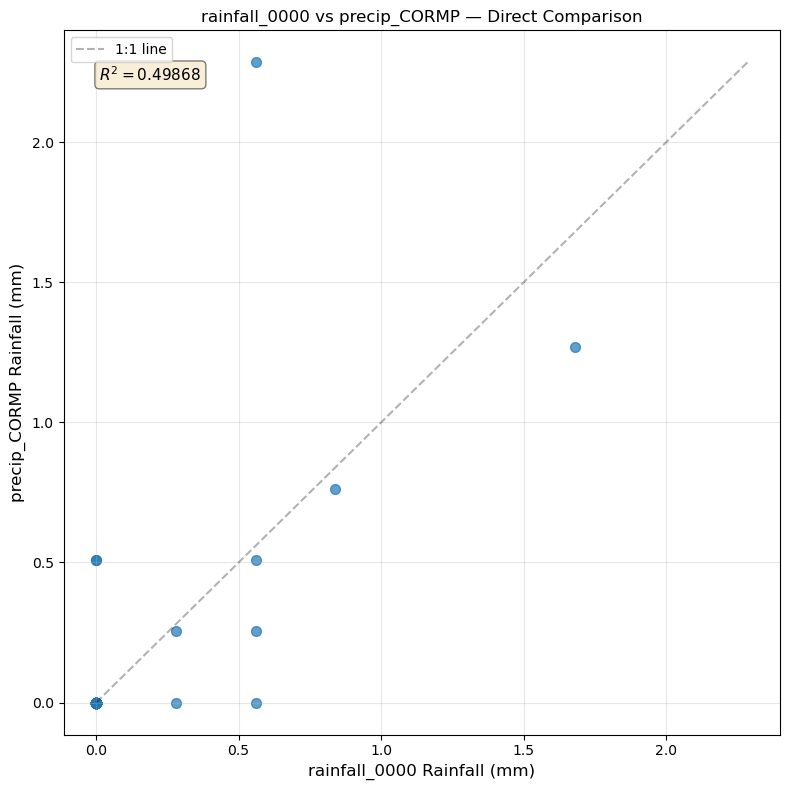

In [15]:
# Compare rainfall_0000 and precip_CORMP directly
# Plot rainfall_0000 on X-axis and precip_CORMP on Y-axis

cormp_only = load_and_process(file_1, assume_inches=True, already_hourly=False)
rain0_cormp = load_and_process(file_3, assume_inches=False, already_hourly=True)

start = pd.to_datetime('2025-12-19 09:00')
end = pd.to_datetime('2026-01-06 09:00')

cormp_only = cormp_only[(cormp_only['datetime'] >= start) & (cormp_only['datetime'] <= end)].reset_index(drop=True)
rain0_cormp = rain0_cormp[(rain0_cormp['datetime'] >= start) & (rain0_cormp['datetime'] <= end)].reset_index(drop=True)

print(f"CORMP shape before rounding: {cormp_only.shape}")
print(f"rainfall_0000 shape before rounding: {rain0_cormp.shape}")

# Round both to nearest HOUR to align hourly data (discard minutes and seconds)
cormp_only['datetime'] = cormp_only['datetime'].dt.floor('H')
rain0_cormp['datetime'] = rain0_cormp['datetime'].dt.floor('H')

print(f"\nAfter rounding to hour:")
print(f"CORMP first 5: {cormp_only['datetime'].head().tolist()}")
print(f"rainfall_0000 first 5: {rain0_cormp['datetime'].head().tolist()}")

# Check for overlapping datetimes
cormp_dates = set(cormp_only['datetime'])
rain0_dates = set(rain0_cormp['datetime'])
overlap = cormp_dates.intersection(rain0_dates)
print(f"\nOverlapping datetimes: {len(overlap)}")

# align datasets on datetime for direct comparison
merged_cr_only = pd.merge(rain0_cormp, cormp_only, on='datetime', how='inner', suffixes=('_rain0','_cormp'))
print(f"Merged shape: {merged_cr_only.shape}")

if not merged_cr_only.empty:
    corr_cr = merged_cr_only['rain_mm_rain0'].corr(merged_cr_only['rain_mm_cormp'])
    r2_cr = corr_cr**2 if pd.notna(corr_cr) else float('nan')
    print(f"R^2: {r2_cr}")
else:
    r2_cr = float('nan')

# Create scatter plot: rainfall_0000 (X) vs precip_CORMP (Y)
plt.figure(figsize=(8,8))
if not merged_cr_only.empty:
    plt.scatter(merged_cr_only['rain_mm_rain0'], merged_cr_only['rain_mm_cormp'], s=50, alpha=0.7)
    print(f"Plotted {len(merged_cr_only)} points")
else:
    print("No data to plot - no overlapping datetimes found")

plt.xlabel('rainfall_0000 Rainfall (mm)', fontsize=12)
plt.ylabel('precip_CORMP Rainfall (mm)', fontsize=12)
plt.title('rainfall_0000 vs precip_CORMP — Direct Comparison', fontsize=12)

# add 1:1 reference line
if not merged_cr_only.empty:
    max_val = max(merged_cr_only['rain_mm_rain0'].max(), merged_cr_only['rain_mm_cormp'].max())
    plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='1:1 line')

# annotate R^2
try:
    ax = plt.gca()
    if pd.notna(r2_cr) and not merged_cr_only.empty:
        ax.text(0.05, 0.95, f'$R^2 = {r2_cr:.5g}$', transform=ax.transAxes, fontsize=11, va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
except Exception:
    pass

if not merged_cr_only.empty:
    plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

R^2 (Davis vs rainfall_0000) [main plot]: nan
R^2 (Davis vs rainfall_0000) [Davis-only plot]: nan
